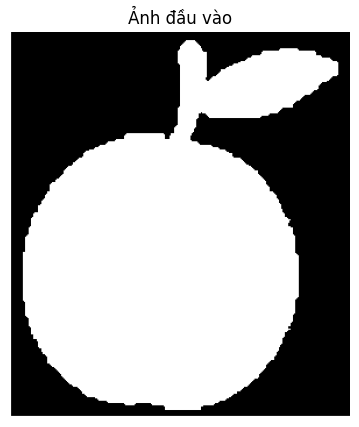

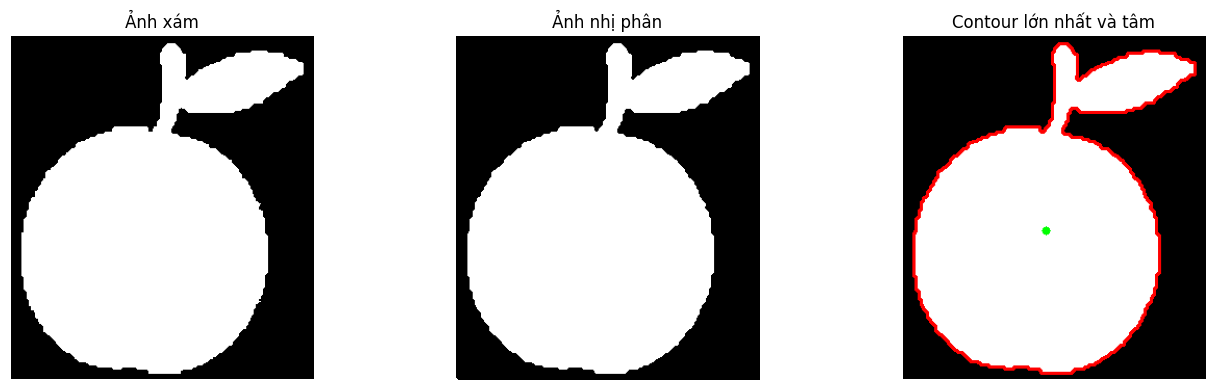

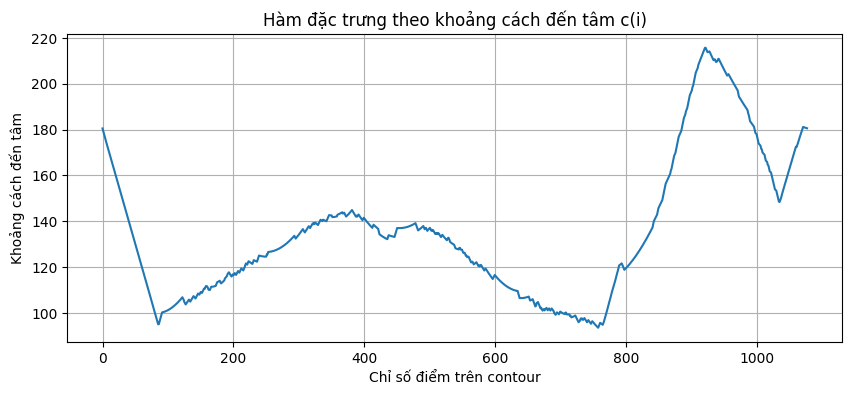

Tâm contour (cx, cy): [137.54784 187.00072]

Các moment thô m_r:
m_1 = 135.379639
m_2 = 19235.315322
m_3 = 2875299.764976
m_4 = 452141176.494664

Các moment trung tâm mu_r:
mu_1 = -0.000000
mu_2 = 907.668742
mu_3 = 25469.993315
mu_4 = 2633481.885763

Các moment chuẩn hóa mbar_r:
mbar_1 = 4.493551
mbar_2 = 21.191999
mbar_3 = 105.145831
mbar_4 = 548.806569

Các moment chuẩn hóa mubar_r:
mubar_1 = -0.000000
mubar_2 = 1.000000
mubar_3 = 0.931403
mubar_4 = 3.196506

Các mô tả bổ sung:
F1 = 0.222541
F2 = 0.931403
F3 = 3.196506

Vector đặc trưng F_BM:
[ 4.49355085e+00  2.11919993e+01  1.05145831e+02  5.48806569e+02
 -9.81044765e-17  1.00000000e+00  9.31403277e-01  3.19650639e+00
  2.22541156e-01  9.31403277e-01  3.19650639e+00]

Kiểm tra hoàn tất: chương trình chạy đúng với ảnh đầu vào hiện tại.


In [1]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: MOMENT BIÊN CỦA ĐƯỜNG BAO ĐỐI TƯỢNG
# Chương/Mục liên quan: Chương 5 - Đặc trưng hình dạng
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa cách trích xuất contour lớn nhất từ ảnh nhị phân.
# - Tính hàm đặc trưng biên c(i) dựa trên khoảng cách từ điểm biên đến tâm.
# - Tính các moment biên và vector đặc trưng F_BM.

# Sau khi chạy code, người học cần:
# 1. Quan sát được contour lớn nhất và tâm của đối tượng.
# 2. Hiểu được cách chuyển đường biên thành tín hiệu 1D c(i).
# 3. Hiểu được cách tính moment thô, moment trung tâm và moment chuẩn hóa.

# Input:
# - Dữ liệu đầu vào: ảnh từ GitHub
# - Kiểu dữ liệu: ảnh màu, đối tượng chính trên nền tương phản

# Output:
# - Ảnh xám
# - Ảnh nhị phân
# - Contour lớn nhất và tâm
# - Đồ thị signature c(i)
# - Các moment và vector đặc trưng F_BM

# Lưu ý:
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen


# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

def read_image_from_url(url):
    resp = urlopen(url)
    img = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    return cv2.imdecode(img, cv2.IMREAD_COLOR)


image_url = "https://github.com/lthavnu/cv-book/raw/main/images/apple_binary.png"

I_bgr = read_image_from_url(image_url)
I_rgb = cv2.cvtColor(I_bgr, cv2.COLOR_BGR2RGB)


# ============================================================
# 3. HIỂN THỊ ẢNH ĐẦU VÀO
# ============================================================

plt.figure(figsize=(5, 5))
plt.imshow(I_rgb)
plt.title("Ảnh đầu vào")
plt.axis("off")
plt.show()


# ============================================================
# 4. XỬ LÝ CHÍNH
# ============================================================

def extract_largest_contour(image_bgr):
    # Chuyển ảnh màu BGR sang ảnh xám
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    # Làm mượt nhẹ để giảm nhiễu trước khi nhị phân hóa
    gray_blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # Nhị phân hóa ảnh bằng ngưỡng Otsu
    _, binary = cv2.threshold(
        gray_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Tìm các contour ngoài cùng của vùng đối tượng
    contours, _ = cv2.findContours(
        binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE
    )

    if len(contours) == 0:
        raise ValueError("Không tìm thấy contour nào trong ảnh.")

    # Chọn contour có diện tích lớn nhất
    largest_contour = max(contours, key=cv2.contourArea)

    return gray, binary, largest_contour


def contour_signature(contour):
    # Chuyển contour từ dạng (N, 1, 2) về dạng (N, 2)
    pts = contour[:, 0, :].astype(np.float32)

    # Tính tâm hình bằng moment hình học
    M = cv2.moments(contour)

    if abs(M["m00"]) < 1e-8:
        raise ValueError("Không tính được tâm contour vì diện tích quá nhỏ.")

    cx = M["m10"] / M["m00"]
    cy = M["m01"] / M["m00"]
    center = np.array([cx, cy], dtype=np.float32)

    # Dòng này tương ứng với hàm signature c(i):
    # c(i) là khoảng cách Euclid từ điểm biên thứ i đến tâm của contour
    c = np.linalg.norm(pts - center, axis=1)

    return pts, center, c


def boundary_moment_features(c, max_r=4):
    # c là signature 1D gồm N giá trị khoảng cách từ điểm biên đến tâm
    c = np.asarray(c, dtype=np.float64)
    N = len(c)

    if N == 0:
        raise ValueError("Signature rỗng.")

    # Tính moment thô m_r = (1/N) * sum(c(i)^r)
    m = {}
    for r in range(1, max_r + 1):
        m[r] = np.mean(c ** r)

    # Tính moment trung tâm mu_r = (1/N) * sum((c(i) - m_1)^r)
    mu = {}
    for r in range(1, max_r + 1):
        mu[r] = np.mean((c - m[1]) ** r)

    # Tránh chia cho 0 khi chuẩn hóa
    eps = 1e-12
    mu2 = max(mu[2], eps)

    # Tính các moment chuẩn hóa
    mbar = {}
    mubar = {}
    for r in range(1, max_r + 1):
        denom = mu2 ** (r / 2.0)
        mbar[r] = m[r] / denom
        mubar[r] = mu[r] / denom

    # Tính các mô tả bổ sung F1, F2, F3
    F1 = np.sqrt(mu2) / (m[1] + eps)
    F2 = mu[3] / (mu2 ** 1.5)
    F3 = mu[4] / (mu2 ** 2)

    # Vector đặc trưng biên F_BM gồm 11 thành phần
    F_BM = np.array([
        mbar[1], mbar[2], mbar[3], mbar[4],
        mubar[1], mubar[2], mubar[3], mubar[4],
        F1, F2, F3
    ], dtype=np.float64)

    return {
        "m": m,
        "mu": mu,
        "mbar": mbar,
        "mubar": mubar,
        "F1": F1,
        "F2": F2,
        "F3": F3,
        "F_BM": F_BM
    }


gray, binary, contour = extract_largest_contour(I_bgr)

pts, center, c = contour_signature(contour)

features = boundary_moment_features(c, max_r=4)


# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

vis = I_rgb.copy()

cv2.drawContours(vis, [contour], -1, (255, 0, 0), 2)

cx, cy = int(round(center[0])), int(round(center[1]))
cv2.circle(vis, (cx, cy), 4, (0, 255, 0), -1)

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Ảnh xám")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(binary, cmap="gray")
plt.title("Ảnh nhị phân")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(vis)
plt.title("Contour lớn nhất và tâm")
plt.axis("off")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(c)
plt.title("Hàm đặc trưng theo khoảng cách đến tâm c(i)")
plt.xlabel("Chỉ số điểm trên contour")
plt.ylabel("Khoảng cách đến tâm")
plt.grid(True)
plt.show()


# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

print("Tâm contour (cx, cy):", center)

print("\nCác moment thô m_r:")
for r in range(1, 5):
    print(f"m_{r} = {features['m'][r]:.6f}")

print("\nCác moment trung tâm mu_r:")
for r in range(1, 5):
    print(f"mu_{r} = {features['mu'][r]:.6f}")

print("\nCác moment chuẩn hóa mbar_r:")
for r in range(1, 5):
    print(f"mbar_{r} = {features['mbar'][r]:.6f}")

print("\nCác moment chuẩn hóa mubar_r:")
for r in range(1, 5):
    print(f"mubar_{r} = {features['mubar'][r]:.6f}")

print("\nCác mô tả bổ sung:")
print(f"F1 = {features['F1']:.6f}")
print(f"F2 = {features['F2']:.6f}")
print(f"F3 = {features['F3']:.6f}")

print("\nVector đặc trưng F_BM:")
print(features["F_BM"])

assert I_bgr is not None, "Lỗi: không đọc được ảnh đầu vào."
assert len(contour) > 0, "Lỗi: contour rỗng."
assert len(c) == len(contour), "Lỗi: số phần tử signature không khớp số điểm contour."
assert features["F_BM"].shape[0] == 11, "Lỗi: vector F_BM không có 11 thành phần."
assert np.all(np.isfinite(features["F_BM"])), "Lỗi: vector F_BM chứa giá trị không hợp lệ."

print("\nKiểm tra hoàn tất: chương trình chạy đúng với ảnh đầu vào hiện tại.")


# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# 1. Thay đổi image_url để tính moment biên cho đối tượng khác.
# 2. Thay đổi kích thước GaussianBlur, ví dụ (3, 3), (7, 7), để quan sát ảnh hưởng đến contour.
# 3. Thay đổi max_r trong boundary_moment_features(c, max_r=4) để mở rộng bậc moment.